In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import grad, jit, jacfwd, jacrev
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
from sklearn.datasets import make_regression
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

from kappaeta import pipeline_forward_jax, loss_function_jax
from kappaeta.jax_ops import grad_loss_jax

# Set random seeds
np.random.seed(42)
key = jax.random.PRNGKey(42)

# Style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)

print(f"JAX version: {jax.__version__}")
print(f"JAX devices: {jax.devices()}")

JAX version: 0.9.2
JAX devices: [CpuDevice(id=0)]


## 1. Create Timing Utils


In [2]:
def generate_dataset(N_train, N_test, d, noise=0.1):
    """Generate synthetic regression dataset."""
    X, y = make_regression(n_samples=N_train + N_test, n_features=d, 
                          noise=noise, random_state=42)
    
    X_train = X[:N_train]
    X_test = X[N_train:]
    y_train = y[:N_train]
    y_test = y[N_train:]
    
    # Scale
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_test = scaler.transform(X_test).astype(np.float32)
    y_train = y_train.astype(np.float32)
    y_test = y_test.astype(np.float32)
    
    return X_train, X_test, y_train, y_test


def time_gradient_computation(X_train, X_test, y_train, y_test, kappa, eta, n_runs=10):
    """Time the computation of first-order gradients."""
    X_train_jax = jnp.array(X_train)
    X_test_jax = jnp.array(X_test)
    y_train_jax = jnp.array(y_train)
    y_test_jax = jnp.array(y_test)
    
    params = {'kappa': jnp.array(kappa), 'eta': jnp.array(eta)}
    
    # Compile first (JIT warm-up)
    _ = grad_loss_jax(params, X_test_jax, X_train_jax, y_train_jax, y_test_jax)
    
    # Time multiple runs
    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        grads = grad_loss_jax(params, X_test_jax, X_train_jax, y_train_jax, y_test_jax)
        # Block until computation completes
        _ = grads['kappa'].block_until_ready()
        end = time.perf_counter()
        times.append(end - start)
    
    return np.median(times)


def time_individual_first_derivatives(X_train, X_test, y_train, y_test, kappa, eta, n_runs=10):
    """Time individual first derivative components."""
    X_train_jax = jnp.array(X_train)
    X_test_jax = jnp.array(X_test)
    y_train_jax = jnp.array(y_train)
    y_test_jax = jnp.array(y_test)
    
    params = {'kappa': jnp.array(kappa), 'eta': jnp.array(eta)}
    
    def loss_fn(params_dict):
        return loss_function_jax(params_dict, X_test_jax, X_train_jax, y_train_jax, y_test_jax)
    
    grad_fn = jit(grad(loss_fn))
    
    # Separate functions for each gradient component
    def dL_deta_fn(params_dict):
        return grad_fn(params_dict)['eta']
    
    def dL_dkappa_fn(params_dict):
        return grad_fn(params_dict)['kappa']
    
    dL_deta_jit = jit(dL_deta_fn)
    dL_dkappa_jit = jit(dL_dkappa_fn)
    
    # Compile
    _ = dL_deta_jit(params)
    _ = dL_dkappa_jit(params)
    
    times = {'dL_deta': [], 'dL_dkappa': []}
    
    for _ in range(n_runs):
        # Time dL/dη
        start = time.perf_counter()
        result = dL_deta_jit(params)
        _ = result.block_until_ready() if hasattr(result, 'block_until_ready') else result
        times['dL_deta'].append(time.perf_counter() - start)
        
        # Time dL/dκ
        start = time.perf_counter()
        result = dL_dkappa_jit(params)
        _ = result.block_until_ready() if hasattr(result, 'block_until_ready') else result
        times['dL_dkappa'].append(time.perf_counter() - start)
    
    return {k: np.median(v) for k, v in times.items()}


def time_hessian_computation(X_train, X_test, y_train, y_test, kappa, eta, n_runs=10):
    """Time the computation of the full Hessian matrix."""
    X_train_jax = jnp.array(X_train)
    X_test_jax = jnp.array(X_test)
    y_train_jax = jnp.array(y_train)
    y_test_jax = jnp.array(y_test)
    
    params = {'kappa': jnp.array(kappa), 'eta': jnp.array(eta)}
    
    # Create Hessian function
    def loss_fn(params_dict):
        return loss_function_jax(params_dict, X_test_jax, X_train_jax, y_train_jax, y_test_jax)
    
    # Hessian via jacfwd(jacrev(loss))
    hessian_fn = jit(jacfwd(jacrev(loss_fn)))
    
    # Compile first
    _ = hessian_fn(params)
    
    # Time multiple runs
    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        hess = hessian_fn(params)
        # Block until computation completes
        _ = hess['kappa']['kappa'].block_until_ready()
        end = time.perf_counter()
        times.append(end - start)
    
    return np.median(times)


def time_individual_second_derivatives(X_train, X_test, y_train, y_test, kappa, eta, n_runs=10):
    """Time individual second derivative components."""
    X_train_jax = jnp.array(X_train)
    X_test_jax = jnp.array(X_test)
    y_train_jax = jnp.array(y_train)
    y_test_jax = jnp.array(y_test)
    
    params = {'kappa': jnp.array(kappa), 'eta': jnp.array(eta)}
    
    def loss_fn(params_dict):
        return loss_function_jax(params_dict, X_test_jax, X_train_jax, y_train_jax, y_test_jax)
    
    # First derivative functions
    grad_fn = jit(grad(loss_fn))
    
    # Second derivatives
    def d2L_deta2_fn(params_dict):
        return grad(lambda p: grad_fn(p)['eta'])(params_dict)['eta']
    
    def d2L_dkappa2_fn(params_dict):
        return grad(lambda p: grad_fn(p)['kappa'])(params_dict)['kappa']
    
    def d2L_dkappa_deta_fn(params_dict):
        return grad(lambda p: grad_fn(p)['kappa'])(params_dict)['eta']
    
    d2L_deta2_jit = jit(d2L_deta2_fn)
    d2L_dkappa2_jit = jit(d2L_dkappa2_fn)
    d2L_dkappa_deta_jit = jit(d2L_dkappa_deta_fn)
    
    # Compile
    _ = d2L_deta2_jit(params)
    _ = d2L_dkappa2_jit(params)
    _ = d2L_dkappa_deta_jit(params)
    
    times = {'d2L_deta2': [], 'd2L_dkappa2': [], 'd2L_dkappa_deta': []}
    
    for _ in range(n_runs):
        # Time d²L/dη²
        start = time.perf_counter()
        result = d2L_deta2_jit(params)
        _ = result.block_until_ready() if hasattr(result, 'block_until_ready') else result
        times['d2L_deta2'].append(time.perf_counter() - start)
        
        # Time d²L/dκ²
        start = time.perf_counter()
        result = d2L_dkappa2_jit(params)
        _ = result.block_until_ready() if hasattr(result, 'block_until_ready') else result
        times['d2L_dkappa2'].append(time.perf_counter() - start)
        
        # Time d²L/dκdη
        start = time.perf_counter()
        result = d2L_dkappa_deta_jit(params)
        _ = result.block_until_ready() if hasattr(result, 'block_until_ready') else result
        times['d2L_dkappa_deta'].append(time.perf_counter() - start)
    
    return {k: np.median(v) for k, v in times.items()}

print("Timing utilities defined.")

Timing utilities defined.


## 2. Scaling Study: Vary N (Training Size)

Fix M and d, then vary N to observe the scaling behavior.

In [3]:
# Fixed parameters
M_fixed = 10  # Test samples
d_fixed = 3   # Features
kappa_init = 2.0
eta_init = 2.0

# Vary N
N_values = [500,1000,1500,2000,2500,3500,4000,4500,5000,5500,6000]

results = {
    'N': [],
    'dL_deta_time': [],
    'dL_dkappa_time': [],
    'gradient_time': [],
    'hessian_time': [],
    'd2L_deta2_time': [],
    'd2L_dkappa2_time': [],
    'd2L_dkappa_deta_time': []
}

print(f"Running scaling study: M={M_fixed}, d={d_fixed}, varying N...\n")

for N in N_values:
    print(f"N = {N}...", end=' ')
    
    # Generate dataset
    X_train, X_test, y_train, y_test = generate_dataset(N, M_fixed, d_fixed)
    
    # Time individual first derivatives
    # TODO these individual times are not needed
    first_deriv_times = time_individual_first_derivatives(X_train, X_test, y_train, y_test,
                                                          kappa_init, eta_init, n_runs=5)
    
    # Time gradient computation (combined)
    grad_time = time_gradient_computation(X_train, X_test, y_train, y_test, 
                                         kappa_init, eta_init, n_runs=5)
    
    # Time full Hessian computation
    hess_time = time_hessian_computation(X_train, X_test, y_train, y_test, 
                                        kappa_init, eta_init, n_runs=5)
    
    # Time individual second derivatives
    # TODO these individual times are not needed
    second_deriv_times = time_individual_second_derivatives(X_train, X_test, y_train, y_test,
                                                            kappa_init, eta_init, n_runs=5)
    
    results['N'].append(N)
    results['dL_deta_time'].append(first_deriv_times['dL_deta'])
    results['dL_dkappa_time'].append(first_deriv_times['dL_dkappa'])
    results['gradient_time'].append(grad_time)
    results['hessian_time'].append(hess_time)
    results['d2L_deta2_time'].append(second_deriv_times['d2L_deta2'])
    results['d2L_dkappa2_time'].append(second_deriv_times['d2L_dkappa2'])
    results['d2L_dkappa_deta_time'].append(second_deriv_times['d2L_dkappa_deta'])
    
    print(f"dL/dη: {first_deriv_times['dL_deta']*1000:.2f}ms, dL/dκ: {first_deriv_times['dL_dkappa']*1000:.2f}ms, Hessian: {hess_time*1000:.2f}ms")

df_results = pd.DataFrame(results)
print("\nScaling study complete!")
df_results

Running scaling study: M=10, d=3, varying N...

N = 500... dL/dη: 2.54ms, dL/dκ: 3.35ms, Hessian: 5.10ms
N = 1000... dL/dη: 8.99ms, dL/dκ: 12.36ms, Hessian: 19.62ms
N = 1500... dL/dη: 24.04ms, dL/dκ: 34.17ms, Hessian: 67.44ms
N = 2000... dL/dη: 45.26ms, dL/dκ: 61.61ms, Hessian: 97.73ms
N = 2500... dL/dη: 64.02ms, dL/dκ: 89.43ms, Hessian: 137.96ms
N = 3500... dL/dη: 121.28ms, dL/dκ: 174.62ms, Hessian: 300.38ms
N = 4000... dL/dη: 235.39ms, dL/dκ: 257.54ms, Hessian: 369.98ms
N = 4500... dL/dη: 193.16ms, dL/dκ: 285.79ms, Hessian: 456.24ms
N = 5000... dL/dη: 240.37ms, dL/dκ: 363.32ms, Hessian: 586.32ms
N = 5500... dL/dη: 296.61ms, dL/dκ: 439.34ms, Hessian: 879.48ms
N = 6000... dL/dη: 345.13ms, dL/dκ: 493.12ms, Hessian: 1437.44ms

Scaling study complete!


,N,dL_deta_time,dL_dkappa_time,gradient_time,hessian_time,d2L_deta2_time,d2L_dkappa2_time,d2L_dkappa_deta_time
0,500,0.002536,0.003353,0.003167,0.005104,0.002493,0.004322,0.003315
1,1000,0.008991,0.012358,0.011955,0.019621,0.008974,0.016605,0.012028
2,1500,0.024045,0.034171,0.034143,0.067438,0.028195,0.050811,0.037292
3,2000,0.045263,0.061612,0.070075,0.097733,0.051031,0.092966,0.065998
4,2500,0.064021,0.089431,0.091789,0.137960,0.063702,0.122619,0.088833
5,3500,0.121282,0.174624,0.184943,0.300383,0.127166,0.279760,0.185689
6,4000,0.235393,0.257544,0.226851,0.369976,0.166637,0.376628,0.239318
7,4500,0.193156,0.285789,0.278400,0.456236,0.194754,0.426232,0.287895
8,5000,0.240368,0.363317,0.368220,0.586323,0.289737,0.576639,0.365160
9,5500,0.296608,0.439341,0.435724,0.879479,0.355538,0.737928,0.459742


## Visualization: Log-Log Plots

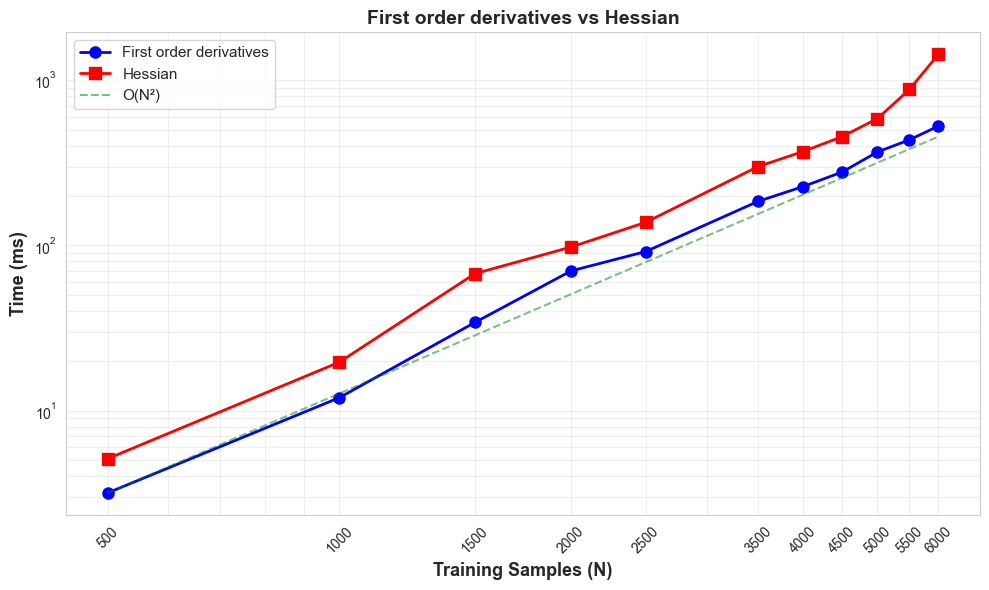

In [4]:
# Combined Gradient vs Full Hessian (single panel) with explicit N tick labels
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

N_vals = np.array(df_results['N'])

# Plot Combined Gradient and Full Hessian
ax.loglog(N_vals, df_results['gradient_time'] * 1000, 'o-', label='First order derivatives', 
         linewidth=2, markersize=8, color='blue')
ax.loglog(N_vals, df_results['hessian_time'] * 1000, 's-', label='Hessian', 
         linewidth=2, markersize=8, color='red')

# Reference line: O(N^2) anchored to the first gradient point
N_ref = np.array([N_vals.min(), N_vals.max()])
ax.loglog(N_ref, (df_results['gradient_time'].iloc[0] * 1000) * (N_ref / N_ref[0])**2, 
         '--', alpha=0.5, label='O(N²)', color='green')

# Formatting
ax.set_xlabel('Training Samples (N)', fontsize=13, fontweight='bold')
ax.set_ylabel('Time (ms)', fontsize=13, fontweight='bold')
ax.set_title('First order derivatives vs Hessian', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')

# Show explicit dataset size ticks and labels
ax.set_xticks(N_vals)
ax.set_xticklabels([str(int(n)) for n in N_vals], rotation=45)

plt.tight_layout()
plt.savefig('hessian_vs_combined_gradient.png', dpi=300, bbox_inches='tight')
plt.show()